<a href="https://colab.research.google.com/github/23424028/Matakuliah_PCD_Pertemuan4/blob/main/PCD_pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

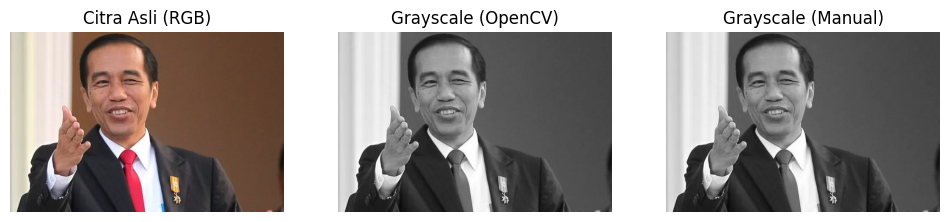

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra / gambar asli (Pastikan file 'gambar.jpg' ada di folder yang sama)
# OpenCV secara default membaca gambar dalam format BGR (Blue, Green, Red)
image_bgr = cv2.imread('IMG_6464.webp')

# Mengubah urutan warna BGR ke RGB agar sesuai untuk ditampilkan dengan matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ==========================================================
# CARA 1: Menggunakan fungsi bawaan dari Library OpenCV (Sangat Cepat & Praktis)
# ==========================================================
image_gray_cv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# ==========================================================
# CARA 2: Menggunakan rumus Luminositas secara manual (Pemahaman Konsep)
# Rumus: 0.299*R + 0.587*G + 0.114*B
# ==========================================================
# Memisahkan channel R, G, dan B
R = image_rgb[:, :, 0]
G = image_rgb[:, :, 1]
B = image_rgb[:, :, 2]

# Menerapkan rumus
image_gray_manual = (0.299 * R) + (0.587 * G) + (0.114 * B)
# Memastikan tipe data kembali menjadi bilangan bulat 8-bit (0-255)
image_gray_manual = image_gray_manual.astype(np.uint8)

# ==========================================================
# Menampilkan Hasilnya
# ==========================================================
plt.figure(figsize=(12, 4))

# Gambar Asli
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Citra Asli (RGB)")
plt.axis('off')

# Hasil OpenCV
plt.subplot(1, 3, 2)
plt.imshow(image_gray_cv, cmap='gray')
plt.title("Grayscale (OpenCV)")
plt.axis('off')

# Hasil Rumus Manual
plt.subplot(1, 3, 3)
plt.imshow(image_gray_manual, cmap='gray')
plt.title("Grayscale (Manual)")
plt.axis('off')

plt.show()

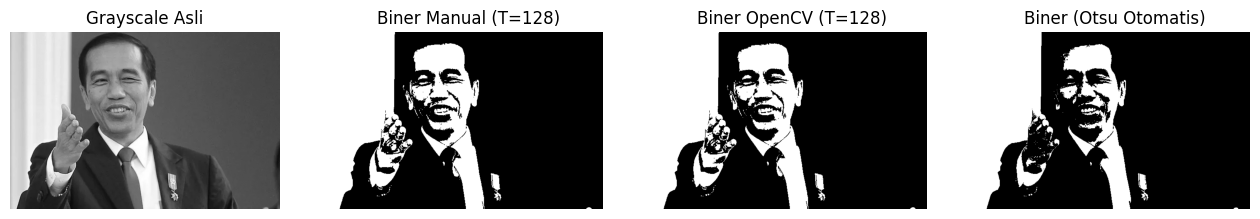

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar langsung ke dalam format Grayscale
# Pastikan ada file 'gambar.jpg' di folder yang sama
image_gray = cv2.imread('IMG_6464.webp', cv2.IMREAD_GRAYSCALE)

# Menentukan nilai batas (threshold) secara manual
nilai_threshold = 128

# ==========================================================
# CARA 1: Cara Manual (Pemahaman Konsep Dasar)
# ==========================================================
# Membuat matriks kosong yang ukurannya sama dengan gambar asli
binary_manual = np.zeros_like(image_gray)

# Menerapkan logika: jika piksel >= threshold jadi 255, sisanya biarkan 0
binary_manual[image_gray >= nilai_threshold] = 255

# ==========================================================
# CARA 2: Menggunakan Fungsi Bawaan OpenCV
# ==========================================================
# cv2.threshold akan mengembalikan dua nilai: nilai threshold yang dipakai, dan gambar hasilnya
_, binary_cv = cv2.threshold(image_gray, nilai_threshold, 255, cv2.THRESH_BINARY)

# ==========================================================
# CARA 3: Menggunakan Otsu's Method (Nilai Threshold Otomatis)
# Otsu akan menganalisis histogram dan mencari nilai threshold paling optimal
# ==========================================================
_, binary_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ==========================================================
# Menampilkan Hasilnya
# ==========================================================
plt.figure(figsize=(16, 4))

# Gambar Grayscale Asli
plt.subplot(1, 4, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Grayscale Asli")
plt.axis('off')

# Hasil Manual
plt.subplot(1, 4, 2)
plt.imshow(binary_manual, cmap='gray')
plt.title(f"Biner Manual (T={nilai_threshold})")
plt.axis('off')

# Hasil OpenCV biasa
plt.subplot(1, 4, 3)
plt.imshow(binary_cv, cmap='gray')
plt.title(f"Biner OpenCV (T={nilai_threshold})")
plt.axis('off')

# Hasil OpenCV dengan Otsu
plt.subplot(1, 4, 4)
plt.imshow(binary_otsu, cmap='gray')
plt.title("Biner (Otsu Otomatis)")
plt.axis('off')

plt.show()

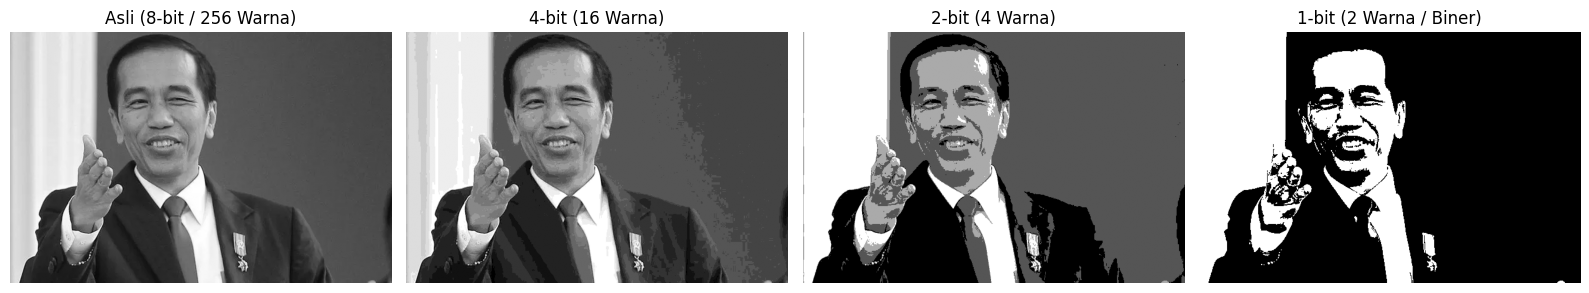

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def konversi_ke_mbit(image_gray, m):
    """
    Fungsi untuk mengkuantisasi gambar grayscale ke m-bit.
    m = kedalaman bit target (1 sampai 8)
    """
    # 1. Tentukan jumlah tingkat warna yang baru (2 pangkat m)
    level_baru = 2 ** m

    # 2. Hitung rentang atau "ukuran kotak" untuk pengelompokan piksel
    # 256 adalah total level pada 8-bit asli
    faktor_pembagi = 256 / level_baru

    # 3. Proses Kuantisasi
    # Piksel dibagi dengan faktor, dibulatkan ke bawah untuk mengelompokkan warna,
    # lalu dikalikan dengan skala baru agar warnanya kembali terentang dari 0 hingga 255 (agar bisa ditampilkan dengan benar).
    image_mbit = np.floor(image_gray / faktor_pembagi) * (255 / (level_baru - 1))

    # Kembalikan tipe data ke format gambar standar (bilangan bulat 8-bit)
    return image_mbit.astype(np.uint8)

# ==========================================================
# Membaca gambar dalam format Grayscale
# ==========================================================
# Pastikan Anda memiliki file 'gambar.jpg' di folder yang sama
image_gray = cv2.imread('IMG_6464.webp', cv2.IMREAD_GRAYSCALE)

# ==========================================================
# Menerapkan konversi ke berbagai variasi m-bit
# ==========================================================
gambar_4bit = konversi_ke_mbit(image_gray, 4) # 16 tingkat warna
gambar_2bit = konversi_ke_mbit(image_gray, 2) # 4 tingkat warna
gambar_1bit = konversi_ke_mbit(image_gray, 1) # 2 tingkat warna (Biner)

# ==========================================================
# Menampilkan Hasil
# ==========================================================
plt.figure(figsize=(16, 5))

# Grayscale Asli (8-bit)
plt.subplot(1, 4, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Asli (8-bit / 256 Warna)")
plt.axis('off')

# Hasil 4-bit
plt.subplot(1, 4, 2)
plt.imshow(gambar_4bit, cmap='gray', vmin=0, vmax=255)
plt.title("4-bit (16 Warna)")
plt.axis('off')

# Hasil 2-bit
plt.subplot(1, 4, 3)
plt.imshow(gambar_2bit, cmap='gray', vmin=0, vmax=255)
plt.title("2-bit (4 Warna)")
plt.axis('off')

# Hasil 1-bit
plt.subplot(1, 4, 4)
plt.imshow(gambar_1bit, cmap='gray', vmin=0, vmax=255)
plt.title("1-bit (2 Warna / Biner)")
plt.axis('off')

plt.tight_layout()
plt.show()

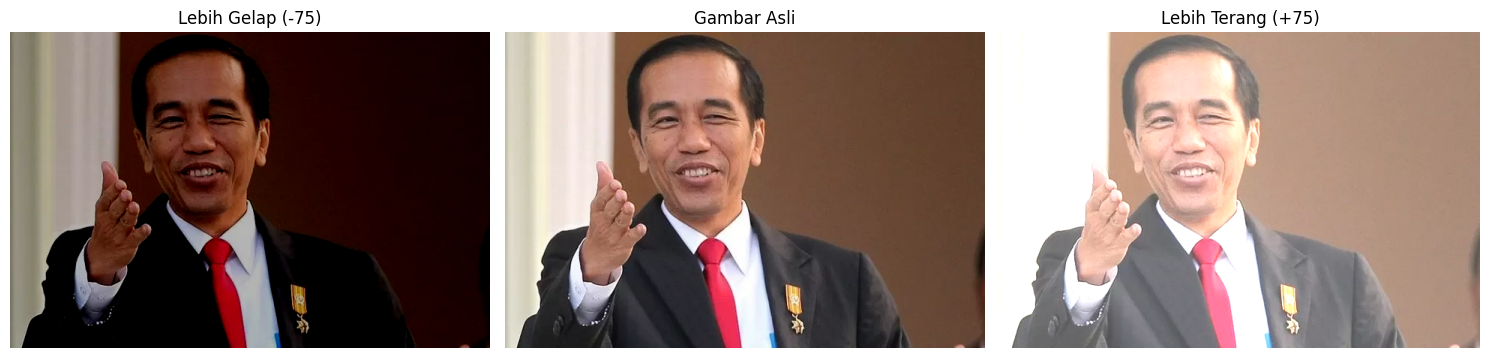

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def atur_kecerahan(image, nilai_kecerahan):
    """
    Fungsi untuk mengatur brightness gambar.
    nilai_kecerahan > 0 akan menerangkan gambar
    nilai_kecerahan < 0 akan menggelapkan gambar
    """
    # Menggunakan cv2.add untuk menambah kecerahan (otomatis membatasi nilai maksimal 255)
    # Menggunakan cv2.subtract untuk mengurangi (otomatis membatasi nilai minimal 0)

    # Membuat matriks/array yang isinya sama dengan nilai_kecerahan
    # dengan ukuran yang sama dengan gambar asli
    matriks_kecerahan = np.ones(image.shape, dtype="uint8") * abs(nilai_kecerahan)

    if nilai_kecerahan > 0:
        # Tambah nilai piksel jika positif (Lebih Terang)
        gambar_hasil = cv2.add(image, matriks_kecerahan)
    elif nilai_kecerahan < 0:
        # Kurangi nilai piksel jika negatif (Lebih Gelap)
        gambar_hasil = cv2.subtract(image, matriks_kecerahan)
    else:
        # Jika nilai 0, gambar tidak berubah
        gambar_hasil = image.copy()

    return gambar_hasil

# ==========================================================
# Membaca gambar (Format RGB agar warnanya benar saat ditampilkan)
# ==========================================================
# Pastikan Anda memiliki file 'gambar.jpg' di folder yang sama
image_bgr = cv2.imread('IMG_6464.webp')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ==========================================================
# Menerapkan pengaturan brightness
# ==========================================================
gambar_terang = atur_kecerahan(image_rgb, 75)   # Menambah kecerahan +75
gambar_gelap = atur_kecerahan(image_rgb, -75)   # Mengurangi kecerahan -75

# ==========================================================
# Menampilkan Hasil
# ==========================================================
plt.figure(figsize=(15, 5))

# Gambar Lebih Gelap
plt.subplot(1, 3, 1)
plt.imshow(gambar_gelap)
plt.title("Lebih Gelap (-75)")
plt.axis('off')

# Gambar Asli
plt.subplot(1, 3, 2)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis('off')

# Gambar Lebih Terang
plt.subplot(1, 3, 3)
plt.imshow(gambar_terang)
plt.title("Lebih Terang (+75)")
plt.axis('off')

plt.tight_layout()
plt.show()

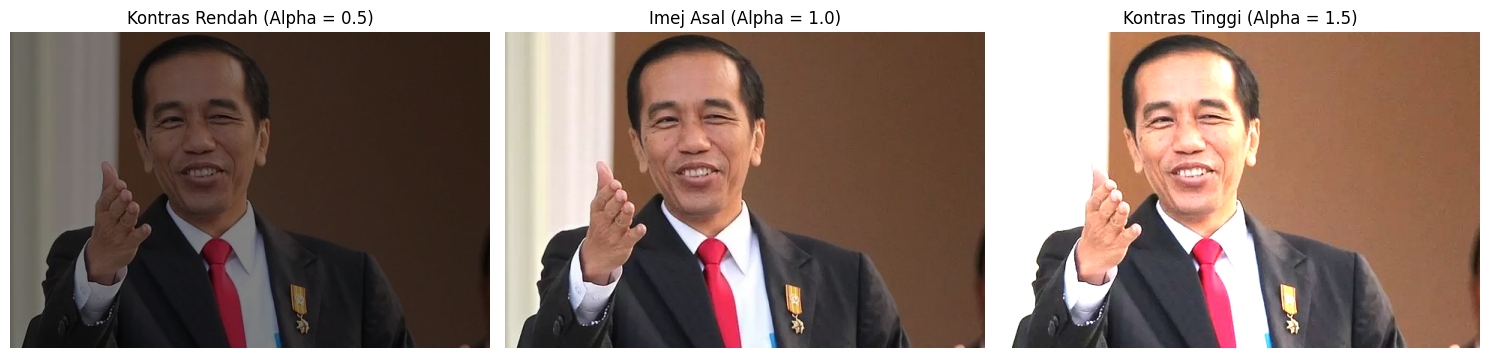

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def atur_kontras(imej, alpha):
    """
    Fungsi untuk melaraskan kontras imej.
    alpha > 1.0 : Meningkatkan kontras (imej lebih tajam/pekat)
    0 < alpha < 1.0 : Mengurangkan kontras (imej lebih pudar/kelabu)
    """
    # cv2.convertScaleAbs melakukan operasi matematik:
    # Hasil = Imej_Asal * alpha + beta
    # Di sini, beta = 0 kerana kita tidak mahu mengubah kecerahan asas, hanya kontras.
    imej_hasil = cv2.convertScaleAbs(imej, alpha=alpha, beta=0)

    return imej_hasil

# ==========================================================
# Membaca imej (Format RGB agar warnanya betul saat dipaparkan)
# ==========================================================
# Pastikan anda mempunyai fail 'gambar.jpg' di dalam folder yang sama
imej_bgr = cv2.imread('IMG_6464.webp')
imej_rgb = cv2.cvtColor(imej_bgr, cv2.COLOR_BGR2RGB)

# ==========================================================
# Menerapkan pelarasan kontras
# ==========================================================
kontras_rendah = atur_kontras(imej_rgb, 0.5)  # Mengurangkan kontras (didarab 0.5)
kontras_tinggi = atur_kontras(imej_rgb, 1.5)  # Meningkatkan kontras (didarab 1.5)

# ==========================================================
# Memaparkan Hasil
# ==========================================================
plt.figure(figsize=(15, 5))

# Imej Kontras Rendah
plt.subplot(1, 3, 1)
plt.imshow(kontras_rendah)
plt.title("Kontras Rendah (Alpha = 0.5)")
plt.axis('off')

# Imej Asal
plt.subplot(1, 3, 2)
plt.imshow(imej_rgb)
plt.title("Imej Asal (Alpha = 1.0)")
plt.axis('off')

# Imej Kontras Tinggi
plt.subplot(1, 3, 3)
plt.imshow(kontras_tinggi)
plt.title("Kontras Tinggi (Alpha = 1.5)")
plt.axis('off')

plt.tight_layout()
plt.show()

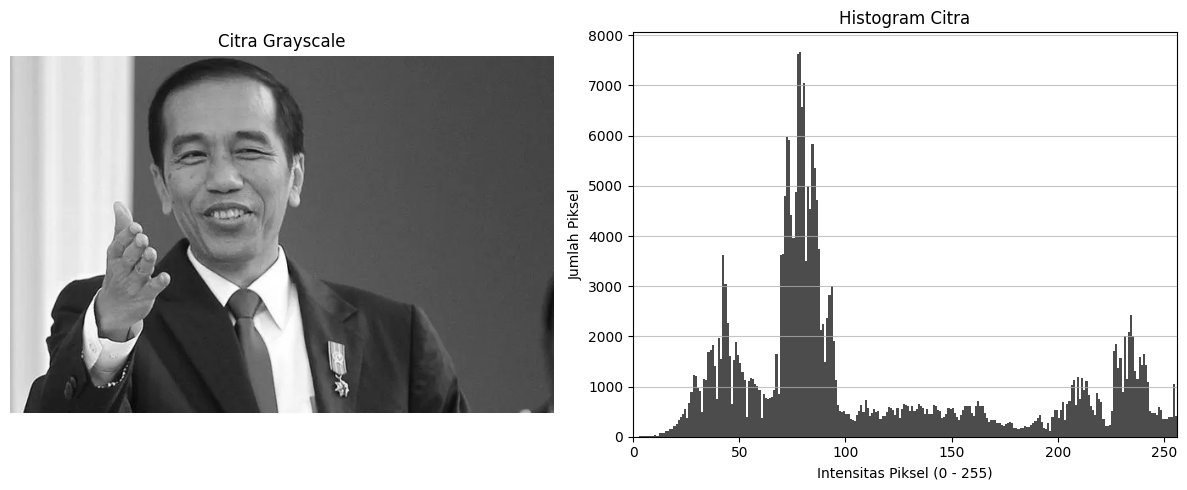

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. Membaca gambar dalam format Grayscale
# ==========================================================
# Pastikan ada file 'gambar.jpg' di folder yang sama
image_gray = cv2.imread('IMG_6464.webp', cv2.IMREAD_GRAYSCALE)

# ==========================================================
# 2. Menghitung Histogram
# ==========================================================
# CARA 1: Menggunakan fungsi bawaan OpenCV (Sangat Cepat)
# Parameter: [gambar], [channel/indeks], mask, [jumlah_bin], [rentang_nilai]
hist_cv = cv2.calcHist([image_gray], [0], None, [256], [0, 256])

# ==========================================================
# 3. Menampilkan Hasil (Gambar & Grafik Histogram)
# ==========================================================
plt.figure(figsize=(12, 5))

# Menampilkan Gambar Grayscale
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray', vmin=0, vmax=255)
plt.title("Citra Grayscale")
plt.axis('off')

# Menampilkan Grafik Histogram menggunakan Matplotlib
plt.subplot(1, 2, 2)
# Menggunakan plt.hist untuk langsung menghitung dan menggambar dari array piksel
# ravel() digunakan untuk meratakan matriks gambar 2D menjadi array 1D
plt.hist(image_gray.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
plt.title("Histogram Citra")
plt.xlabel("Intensitas Piksel (0 - 255)")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256]) # Membatasi sumbu X dari 0 hingga 255
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

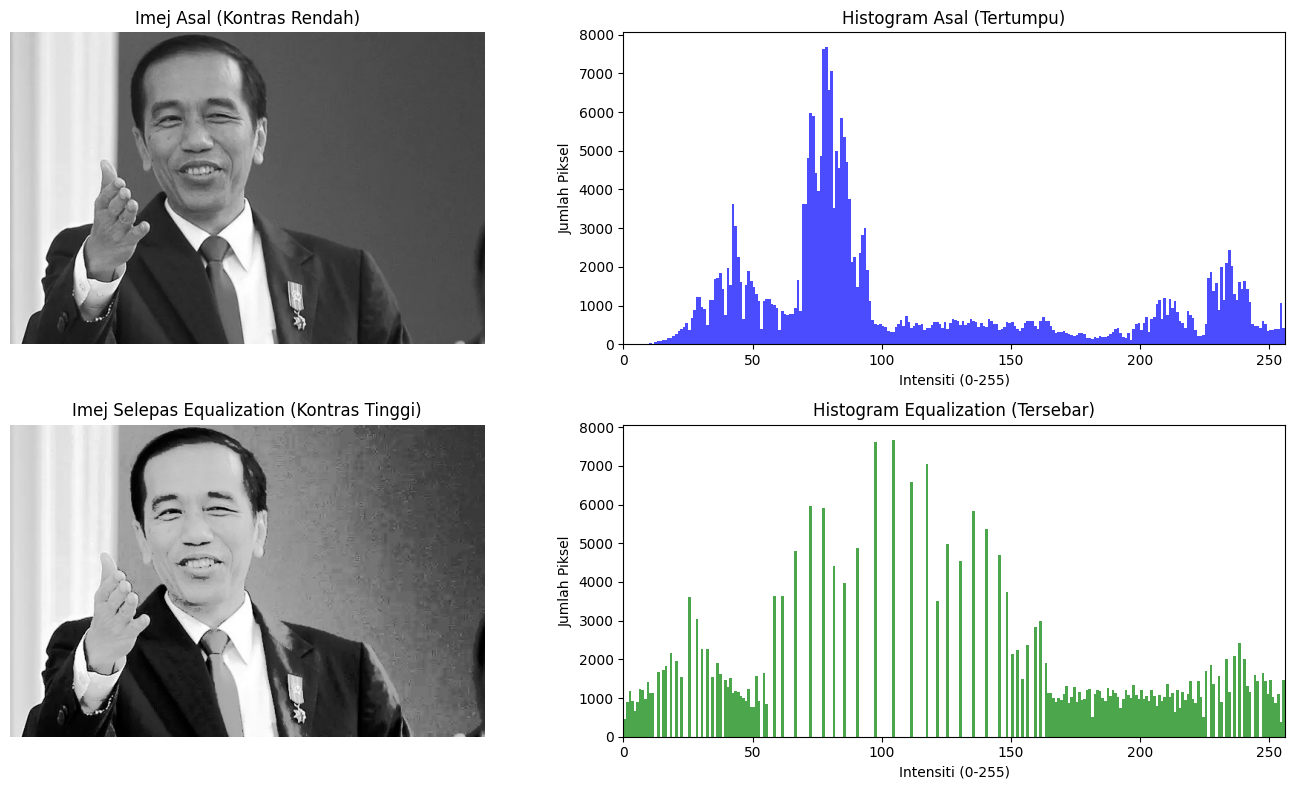

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. Membaca imej dalam format Grayscale (Skala Kelabu)
# ==========================================================
# Pastikan fail 'gambar.jpg' ada di dalam folder yang sama
# Proses ini biasanya dilakukan pada imej skala kelabu
imej_asal = cv2.imread('IMG_6464.webp', cv2.IMREAD_GRAYSCALE)

# ==========================================================
# 2. Melaksanakan Histogram Equalization
# ==========================================================
# Fungsi ini secara automatik meratakan taburan warna kelabu
imej_eq = cv2.equalizeHist(imej_asal)

# ==========================================================
# 3. Memaparkan Hasil (Imej & Graf Histogram)
# ==========================================================
plt.figure(figsize=(14, 8))

# --- BARIS 1: IMEJ ASAL & HISTOGRAMNYA ---

# Memaparkan Imej Asal
plt.subplot(2, 2, 1)
plt.imshow(imej_asal, cmap='gray', vmin=0, vmax=255)
plt.title("Imej Asal (Kontras Rendah)")
plt.axis('off')

# Memaparkan Histogram Imej Asal
plt.subplot(2, 2, 2)
plt.hist(imej_asal.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title("Histogram Asal (Tertumpu)")
plt.xlabel("Intensiti (0-255)")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])

# --- BARIS 2: IMEJ SELEPAS EQUALIZATION & HISTOGRAMNYA ---

# Memaparkan Imej Selepas Histogram Equalization
plt.subplot(2, 2, 3)
plt.imshow(imej_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Imej Selepas Equalization (Kontras Tinggi)")
plt.axis('off')

# Memaparkan Histogram Selepas Equalization
plt.subplot(2, 2, 4)
plt.hist(imej_eq.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title("Histogram Equalization (Tersebar)")
plt.xlabel("Intensiti (0-255)")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()